#### PCA

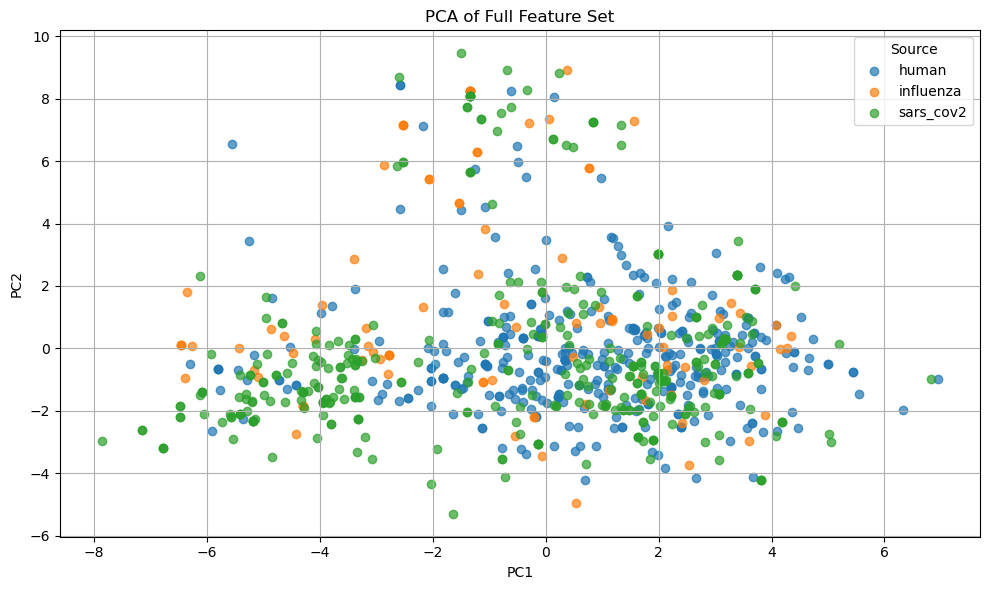

Variance explained by PC1: 6.20%
Variance explained by PC2: 4.83%


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Step 1: Load the dataset
df = pd.read_csv("all_data_normalized.tsv", sep="\t")

# Step 2: Select all numerical columns (exclude strings or metadata)
exclude_cols = ['pdb', 'heavy_chain', 'CDR_H1', 'CDR_H2', 'CDR_H3', 'source']
numeric_cols = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]

# Step 3: Extract feature matrix (including any typo columns)
X = df[numeric_cols].copy()

# Step 4: Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 6: Create PCA results DataFrame
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["source"] = df["source"]

# Step 7: Plot PCA result
plt.figure(figsize=(10, 6))
for group in pca_df["source"].unique():
    subset = pca_df[pca_df["source"] == group]
    plt.scatter(subset["PC1"], subset["PC2"], label=group, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Full Feature Set")
plt.legend(title="Source")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 8: Print explained variance
explained = pca.explained_variance_ratio_
print(f"Variance explained by PC1: {explained[0]:.2%}")
print(f"Variance explained by PC2: {explained[1]:.2%}")
